# new

Please upload your Kolam Rangoli image...


Saving bb832316e2b525cde71c4cdfe80d1c6c.jpg to bb832316e2b525cde71c4cdfe80d1c6c.jpg

IMAGE INFORMATION:
  Filename:   bb832316e2b525cde71c4cdfe80d1c6c.jpg
  File Type:  JPG
  Dimensions: 236 x 247 pixels
  File Size:  19.17 KB


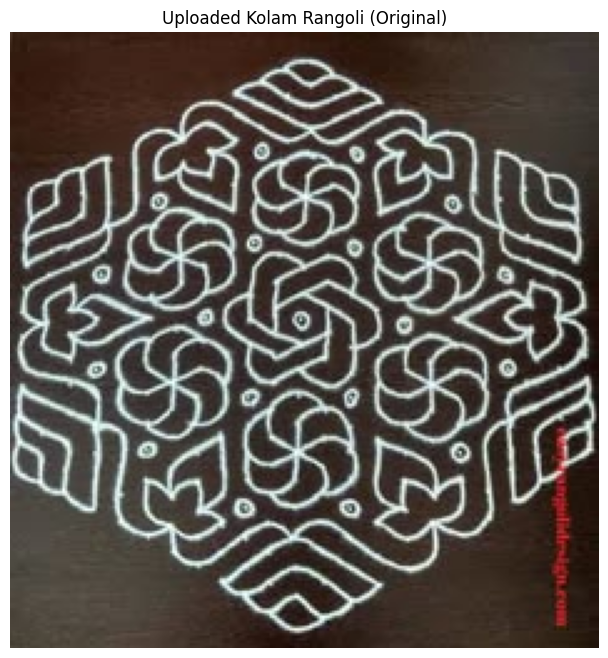

Processing dimensions: 236 x 247 pixels

Detecting rangoli boundary...
Finding precise center...
Validating rangoli...
Valid rangoli detected! (Confidence: 77.7%)
ROI dimensions: 236 x 247 pixels
Center: (118, 122)

KOLAM RANGOLI ANALYSIS REPORT

IMAGE ANALYSIS VISUALIZATIONS

IMAGE 1: DETECTED CENTER OF RANGOLI


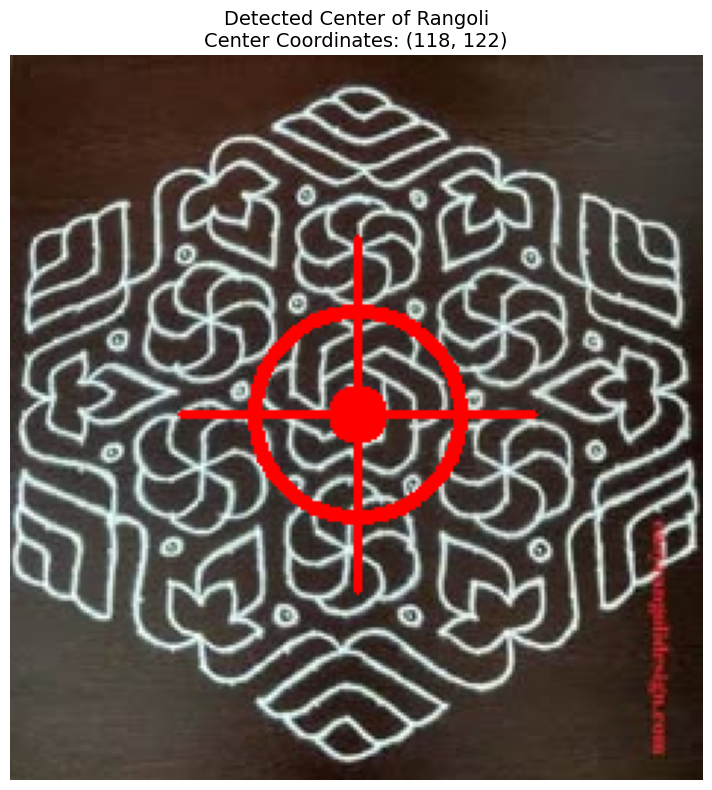

  Center detected at: (118, 122)

IMAGE 2: DETECTED RANGOLI BOUNDARY


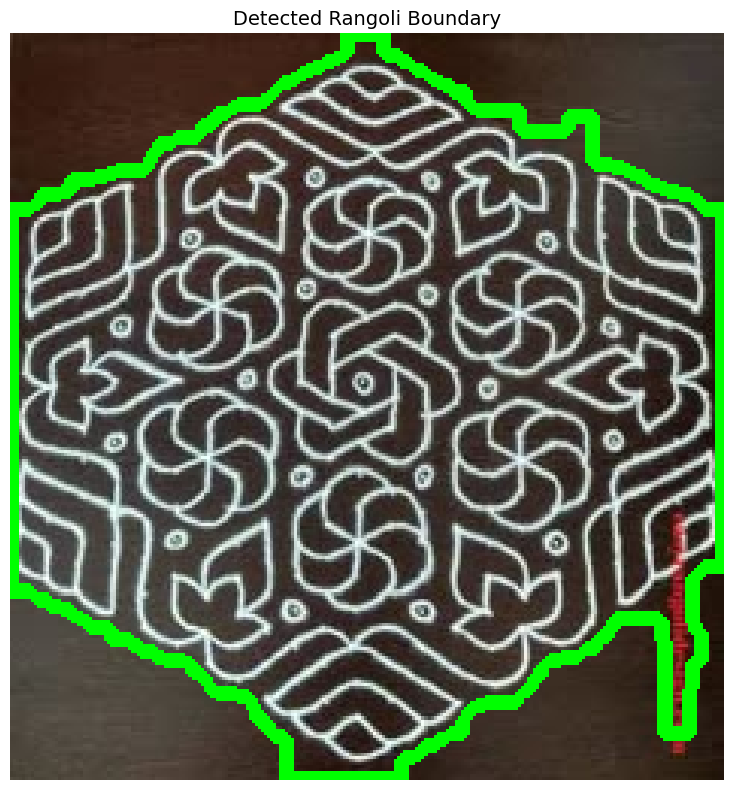

  ✅ Rangoli ROI extracted: 236 x 247 pixels

⚫ IMAGE 3: DETECTED DOTS IN RANGOLI
--------------------------------------------------


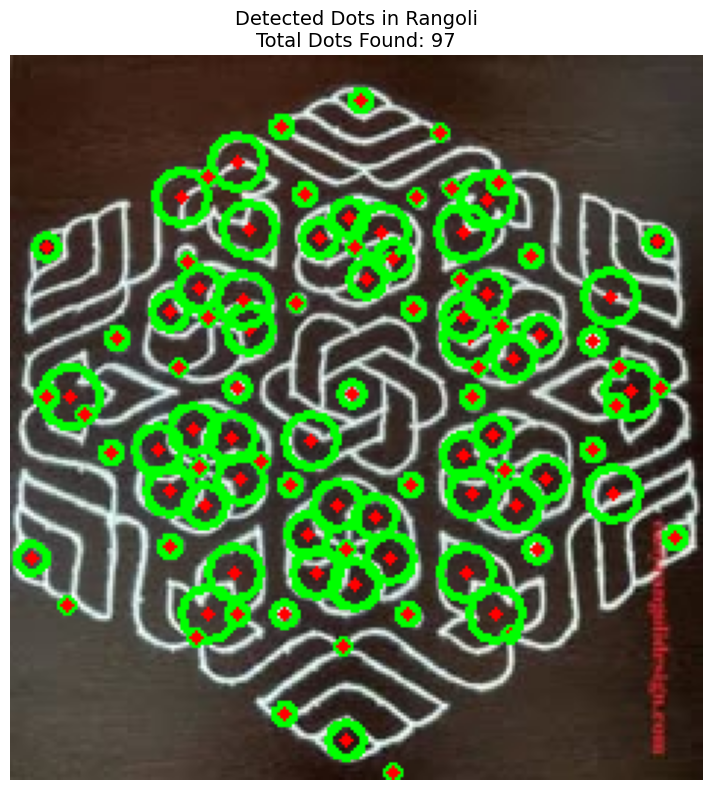

  ✅ Total dots detected: 97
  Mean dot spacing: 13.91px

IMAGE 4: EDGE DETECTION IMAGE


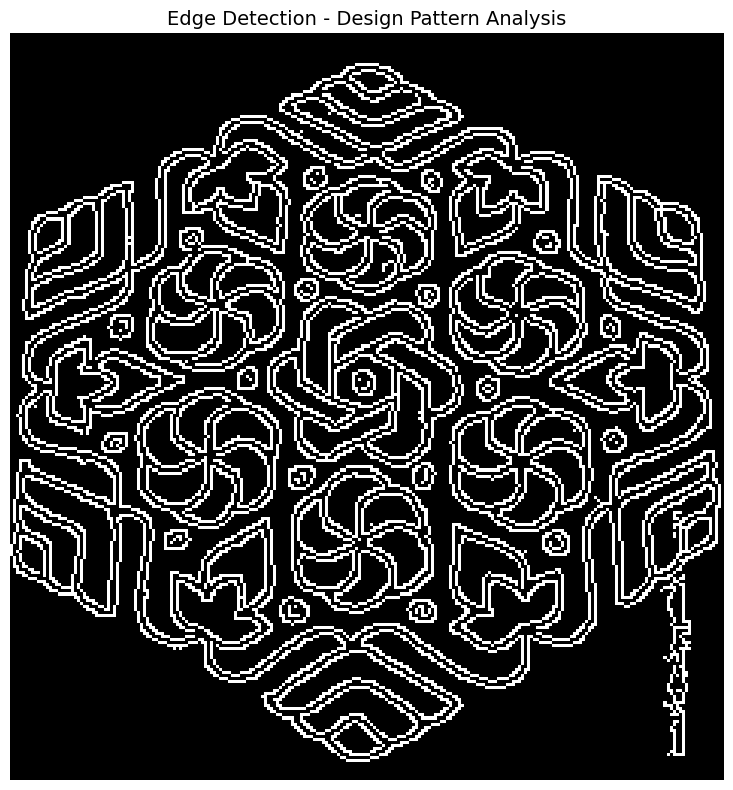

  Edge density: 17.86%
  Total line length: 20401.0px

IMAGE 5: SYMMETRY ANALYSIS (VERTICAL & HORIZONTAL LINES)


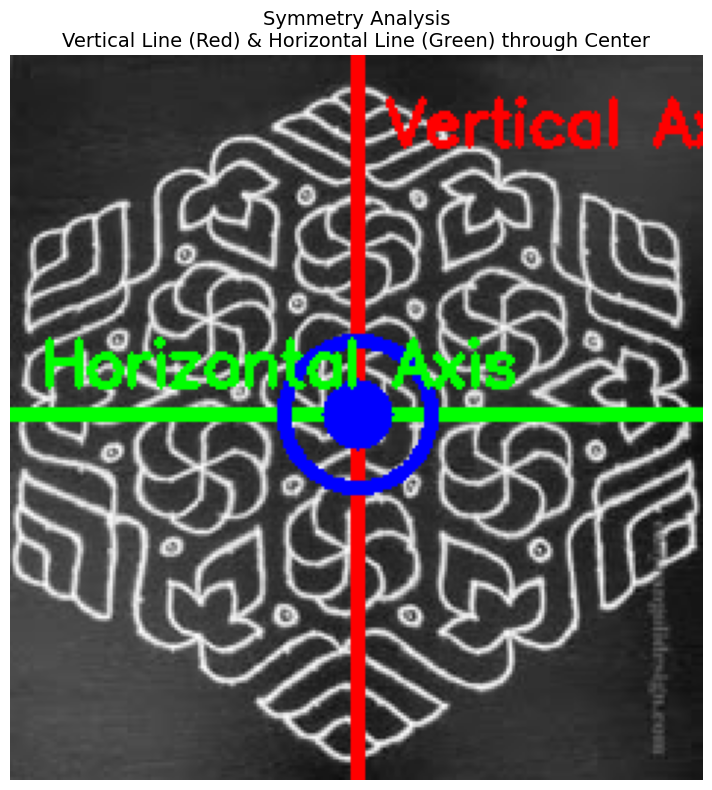

  Vertical Symmetry: 63.92%
  Horizontal Symmetry: 54.94%
  Detected symmetry types: []


ANALYSIS METRIC VALUES

1. DOT PLACEMENT & GRID (Max: 20 points)
    | Grid Uniformity:        5.23/8 pts
    | Grid Alignment:         4.7/6 pts
    | Dot Distribution:       4.0/4 pts
    | Grid Type Consistency:  1.19/2 pts
    +-- TOTAL SCORE:          15.11/20 pts

    Details:
      Detected dots: 97
      Mean spacing: 13.91px
      Spacing CV: 0.3773
      Rows detected: 11
      Columns detected: 13
      Grid type: triangular/hexagonal
      Quadrant distribution: [23, 28, 28, 18]

2. SYMMETRY (Max: 20 points)
    | Symmetry Type Detection:    1.28/6 pts
    | Symmetry Accuracy (IoU):    4.18/10 pts
    | Symmetry Completeness:      2.4/4 pts
    +-- TOTAL SCORE:              7.86/20 pts

    IoU Values by Axis:
      Vertical (L-R):    63.92%
      Horizontal (T-B):  54.94%
      Diagonal 45:       55.18%
      Diagonal 135:      57.49%
      Average IoU:       57.88%

    Symmetry Deta

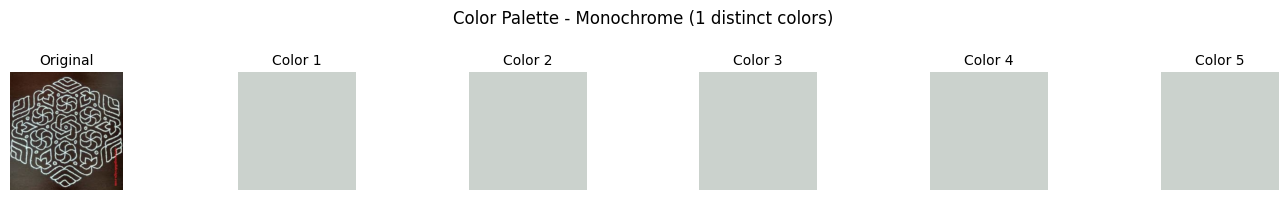



FINAL EVALUATION RESULTS

FINAL SCORE SUMMARY
    1. DOT PLACEMENT & GRID:       15.1/20 pts
    2. SYMMETRY:                    9.0/23 pts
    3. COMPLEXITY:                 16.7/17 pts
    4. CLEANLINESS & PRECISION:    16.4/23 pts
    5. COLOR HARMONY:              13.6/17 pts
       (Monochrome scoring applied)

    FINAL SCORE: 70.8/100

GRADE
    B+ (Good)

OVERALL FEEDBACK
    "Good kolam with nice overall appearance!"

DETAILED FEEDBACK FOR ALL 5 METRICS

1. DOT PLACEMENT & GRID FEEDBACK:
   Good dot pattern with minor spacing variations.

2. SYMMETRY FEEDBACK:
   Try using the center point as reference for better balance.

3. COMPLEXITY FEEDBACK:
   Wonderfully intricate patterns with excellent detail!

4. CLEANLINESS & PRECISION FEEDBACK:
   Beautifully clean lines with great precision!

5. COLOR HARMONY FEEDBACK:
   Beautiful monochrome rangoli with excellent contrast!

OVERALL ENCOURAGEMENT:
   This is a LOVELY kolam with good craftsmanship!


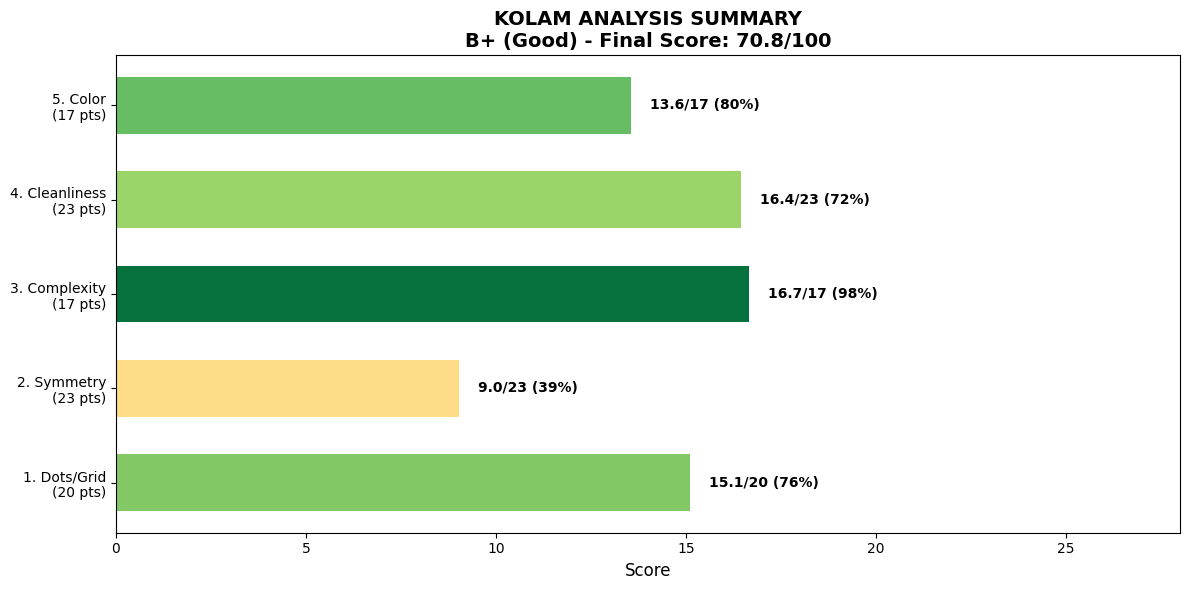


Report saved as 'kolam_analysis_report.png'


In [ ]:
# Kolam Rangoli Analyzer - Google Colab

import cv2
import numpy as np
import matplotlib.pyplot as plt
import math
import os
import warnings
from google.colab import files
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LinearRegression
from scipy.spatial.distance import cdist
warnings.filterwarnings('ignore')

# Upload Image
print("Please upload your Kolam Rangoli image...")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Get file metadata
file_bytes_raw = uploaded[filename]
file_size_bytes = len(file_bytes_raw)
if file_size_bytes >= 1024 * 1024:
    file_size_str = f"{file_size_bytes / (1024 * 1024):.2f} MB"
elif file_size_bytes >= 1024:
    file_size_str = f"{file_size_bytes / 1024:.2f} KB"
else:
    file_size_str = f"{file_size_bytes} bytes"
file_extension = filename.split('.')[-1].upper() if '.' in filename else "Unknown"
temp_img = cv2.imdecode(np.frombuffer(file_bytes_raw, np.uint8), cv2.IMREAD_COLOR)
original_height, original_width = temp_img.shape[:2]

print(f"\nIMAGE INFORMATION:")
print(f"  Filename:   {filename}")
print(f"  File Type:  {file_extension}")
print(f"  Dimensions: {original_width} x {original_height} pixels")
print(f"  File Size:  {file_size_str}")

def load_image(filename):
    """Load and convert image to RGB format"""
    file_bytes = np.frombuffer(uploaded[filename], np.uint8)
    img = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)
    return img, cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def resize_image(img, max_size=800):
    """Resize image maintaining aspect ratio"""
    h, w = img.shape[:2]
    if max(h, w) > max_size:
        scale = max_size / max(h, w)
        img = cv2.resize(img, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_AREA)
    return img

img_bgr, img_rgb = load_image(filename)
img_bgr = resize_image(img_bgr)
img_rgb = resize_image(img_rgb)

plt.figure(figsize=(10, 8))
plt.imshow(img_rgb)
plt.title("Uploaded Kolam Rangoli (Original)")
plt.axis('off')
plt.show()

print(f"Processing dimensions: {img_rgb.shape[1]} x {img_rgb.shape[0]} pixels")

def detect_rangoli_boundary(img):
    """Detect the boundary of the rangoli and extract ROI"""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    binary = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY_INV, 21, 10)
    kernel = np.ones((5, 5), np.uint8)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=3)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=2)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        h, w = gray.shape
        return img, (0, 0, w, h), np.ones(gray.shape, dtype=np.uint8) * 255, (w // 2, h // 2), None

    largest_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest_contour)
    padding = int(min(w, h) * 0.05)
    x, y = max(0, x - padding), max(0, y - padding)
    w = min(img.shape[1] - x, w + 2*padding)
    h = min(img.shape[0] - y, h + 2*padding)

    cropped_img = img[y:y+h, x:x+w]
    boundary_mask = np.zeros((h, w), dtype=np.uint8)
    adjusted_contour = largest_contour - [x, y]
    cv2.drawContours(boundary_mask, [adjusted_contour], -1, 255, -1)
    boundary_mask = cv2.GaussianBlur(boundary_mask, (15, 15), 0)

    M = cv2.moments(adjusted_contour)
    if M['m00'] != 0:
        center_x, center_y = int(M['m10'] / M['m00']), int(M['m01'] / M['m00'])
    else:
        center_x, center_y = w // 2, h // 2

    return cropped_img, (x, y, w, h), boundary_mask, (center_x, center_y), largest_contour

def find_precise_center(img, mask):
    """Find precise center using mask centroid and edge density"""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape

    moments = cv2.moments(mask)
    if moments['m00'] != 0:
        cx1, cy1 = int(moments['m10'] / moments['m00']), int(moments['m01'] / moments['m00'])
    else:
        cx1, cy1 = w // 2, h // 2

    edges = cv2.Canny(gray, 50, 150)
    edges_masked = cv2.bitwise_and(edges, edges, mask=mask)
    y_coords, x_coords = np.where(edges_masked > 0)
    if len(x_coords) > 0:
        cx2, cy2 = int(np.mean(x_coords)), int(np.mean(y_coords))
    else:
        cx2, cy2 = cx1, cy1

    final_cx = int(0.6 * cx1 + 0.4 * cx2)
    final_cy = int(0.6 * cy1 + 0.4 * cy2)
    confidence = min(1.0, (np.sum(mask > 0) / mask.size) * 2)
    return (final_cx, final_cy), confidence

def validate_rangoli(img, mask=None):
    """Check if uploaded image is a valid rangoli pattern"""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    validation_scores = {}

    # Edge structure analysis
    edges = cv2.Canny(gray, 50, 150)
    edge_density = np.sum(edges > 0) / edges.size
    if 0.03 < edge_density < 0.35:
        validation_scores['edge_structure'] = min(100, edge_density * 300)
    else:
        validation_scores['edge_structure'] = max(0, 50 - abs(edge_density - 0.15) * 200)

    # Symmetry check
    center_x, center_y = w // 2, h // 2
    size = min(center_x, center_y, w - center_x, h - center_y) - 10
    if size > 50:
        region = gray[center_y - size:center_y + size, center_x - size:center_x + size]
        sym_h = 1 - np.mean(np.abs(region.astype(float) - cv2.flip(region, 1).astype(float))) / 255
        sym_v = 1 - np.mean(np.abs(region.astype(float) - cv2.flip(region, 0).astype(float))) / 255
        sym_r = 1 - np.mean(np.abs(region.astype(float) - cv2.rotate(region, cv2.ROTATE_180).astype(float))) / 255
        validation_scores['symmetry'] = (sym_h + sym_v + sym_r) / 3 * 100
    else:
        validation_scores['symmetry'] = 30

    # Line patterns
    lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=30, minLineLength=20, maxLineGap=10)
    if lines is not None:
        validation_scores['line_patterns'] = min(100, len(lines) * 2) if len(lines) > 10 else len(lines) * 8
    else:
        validation_scores['line_patterns'] = 10

    # Circular patterns
    circles = cv2.HoughCircles(gray, cv2.HOUGH_GRADIENT, dp=1.2, minDist=30,
                               param1=50, param2=40, minRadius=10, maxRadius=100)
    validation_scores['circular_patterns'] = min(100, len(circles[0]) * 15) if circles is not None else 20

    # Contour complexity
    contours, _ = cv2.findContours(edges, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    closed_contours, complex_contours = 0, 0
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area > 100:
            closed_contours += 1
            if len(cv2.approxPolyDP(cnt, 0.02 * cv2.arcLength(cnt, True), True)) > 6:
                complex_contours += 1
    validation_scores['contour_complexity'] = min(100, complex_contours * 5 + closed_contours * 2) if closed_contours > 5 else closed_contours * 10

    # Color separation
    v_std = np.std(cv2.cvtColor(img, cv2.COLOR_BGR2HSV)[:,:,2])
    if 30 < v_std < 100:
        validation_scores['color_separation'] = 80
    elif v_std > 100:
        validation_scores['color_separation'] = 50
    else:
        validation_scores['color_separation'] = max(20, v_std * 2)

    # Pattern repetition
    gray_small = cv2.resize(gray, (100, 100))
    gray_norm = (gray_small - np.mean(gray_small)) / (np.std(gray_small) + 1e-6)
    q1, q2, q3 = gray_norm[:50, :50], gray_norm[:50, 50:], gray_norm[50:, :50]
    sim1 = np.corrcoef(q1.flatten(), np.flip(q2, axis=1).flatten())[0, 1]
    sim2 = np.corrcoef(q1.flatten(), np.flip(q3, axis=0).flatten())[0, 1]
    if not np.isnan(sim1) and not np.isnan(sim2):
        validation_scores['pattern_repetition'] = (max(0, sim1) + max(0, sim2)) / 2 * 100
    else:
        validation_scores['pattern_repetition'] = 30

    # Calculate overall score
    weights = {'symmetry': 0.25, 'edge_structure': 0.15, 'line_patterns': 0.15,
               'circular_patterns': 0.10, 'contour_complexity': 0.15,
               'color_separation': 0.10, 'pattern_repetition': 0.10}
    overall_score = sum(validation_scores[k] * weights[k] for k in weights)
    is_rangoli = overall_score >= 35
    if validation_scores['symmetry'] < 25:
        is_rangoli, overall_score = False, min(overall_score, 30)

    reason = None
    if not is_rangoli:
        reasons = []
        if validation_scores['symmetry'] < 30: reasons.append("lacks symmetry")
        if validation_scores['edge_structure'] < 25: reasons.append("unclear pattern structure")
        if validation_scores['line_patterns'] < 30 and validation_scores['circular_patterns'] < 30:
            reasons.append("missing geometric patterns")
        reason = "This image " + (", ".join(reasons) if reasons else "doesn't match rangoli characteristics") + "."

    return {'is_valid': is_rangoli, 'confidence': round(overall_score, 2), 'details': validation_scores, 'reason': reason}

# Detect rangoli boundary and extract ROI
print("\nDetecting rangoli boundary...")
roi_bgr, bbox, roi_mask, initial_center, rangoli_contour = detect_rangoli_boundary(img_bgr)
roi_rgb = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2RGB)

print("Finding precise center...")
rangoli_center, center_confidence = find_precise_center(roi_bgr, roi_mask)

# Validate if this is a rangoli
print("Validating rangoli...")
validation_result = validate_rangoli(roi_bgr, roi_mask)

if not validation_result['is_valid']:
    print(f"\nNOT A VALID RANGOLI IMAGE")
    print(f"Confidence: {validation_result['confidence']}/100")
    print(f"Reason: {validation_result['reason']}")
    plt.figure(figsize=(8, 8))
    plt.imshow(img_rgb)
    plt.title(f"Not a Rangoli (Confidence: {validation_result['confidence']:.1f}%)")
    plt.axis('off')
    plt.show()
    raise SystemExit("Please upload a valid rangoli image.")

print(f"Valid rangoli detected! (Confidence: {validation_result['confidence']:.1f}%)")
print(f"ROI dimensions: {roi_rgb.shape[1]} x {roi_rgb.shape[0]} pixels")
print(f"Center: ({rangoli_center[0]}, {rangoli_center[1]})")

img_bgr = roi_bgr
img_rgb = roi_rgb

# ============================================
# STEP 3: DOT PLACEMENT & GRID QUALITY (20 points)
# ============================================

def analyze_dot_grid_quality(dots, img_shape, center=None):
    """Analyze dot grid quality (20 pts): Uniformity(8), Alignment(6), Distribution(4), Consistency(2)"""
    H, W = img_shape[:2]
    n = len(dots)

    if n < 3:
        return {'grid_uniformity': 0, 'grid_alignment': 0, 'dot_distribution': 0,
                'grid_type_consistency': 0, 'total_score': 0, 'details': {'error': 'Not enough dots'}}

    points = np.array([(d['x'], d['y']) for d in dots])
    nn = NearestNeighbors(n_neighbors=min(5, n)).fit(points)
    distances, indices = nn.kneighbors(points)
    nn_distances = distances[:, 1] if distances.shape[1] > 1 else distances[:, 0]
    mean_dist = np.mean(nn_distances)
    cv = np.std(nn_distances) / (mean_dist + 1e-6)

    # Grid Uniformity (8 pts)
    if cv < 0.15: uniformity_ratio = 1.0
    elif cv < 0.30: uniformity_ratio = 0.75 + (0.30 - cv) / 0.15 * 0.25
    elif cv < 0.50: uniformity_ratio = 0.50 + (0.50 - cv) / 0.20 * 0.25
    else: uniformity_ratio = max(0, 0.50 - (cv - 0.50))
    grid_uniformity = uniformity_ratio * 8

    # Grid Alignment (6 pts)
    alignment_scores = []
    row_threshold = mean_dist * 0.3
    y_sorted = np.sort(points[:, 1])
    row_groups, current_row = [], [y_sorted[0]]
    for i in range(1, len(y_sorted)):
        if y_sorted[i] - current_row[-1] < row_threshold: current_row.append(y_sorted[i])
        else:
            if len(current_row) >= 2: row_groups.append(current_row)
            current_row = [y_sorted[i]]
    if len(current_row) >= 2: row_groups.append(current_row)

    for row_y in row_groups:
        row_points = points[np.isin(points[:, 1], row_y)]
        if len(row_points) >= 3:
            model = LinearRegression().fit(row_points[:, 0].reshape(-1, 1), row_points[:, 1])
            residuals = np.abs(row_points[:, 1] - model.predict(row_points[:, 0].reshape(-1, 1)))
            alignment_scores.append(1 - min(1, np.mean(residuals) / mean_dist))

    x_sorted = np.sort(points[:, 0])
    col_groups, current_col = [], [x_sorted[0]]
    for i in range(1, len(x_sorted)):
        if x_sorted[i] - current_col[-1] < row_threshold: current_col.append(x_sorted[i])
        else:
            if len(current_col) >= 2: col_groups.append(current_col)
            current_col = [x_sorted[i]]
    if len(current_col) >= 2: col_groups.append(current_col)

    for col_x in col_groups:
        col_points = points[np.isin(points[:, 0], col_x)]
        if len(col_points) >= 3:
            model = LinearRegression().fit(col_points[:, 1].reshape(-1, 1), col_points[:, 0])
            residuals = np.abs(col_points[:, 0] - model.predict(col_points[:, 1].reshape(-1, 1)))
            alignment_scores.append(1 - min(1, np.mean(residuals) / mean_dist))
    grid_alignment = (np.mean(alignment_scores) if alignment_scores else 0.5) * 6

    # Dot Distribution (4 pts)
    cx, cy = center if center else (W // 2, H // 2)
    quadrant_counts = np.array([
        np.sum((points[:, 0] < cx) & (points[:, 1] < cy)),
        np.sum((points[:, 0] >= cx) & (points[:, 1] < cy)),
        np.sum((points[:, 0] < cx) & (points[:, 1] >= cy)),
        np.sum((points[:, 0] >= cx) & (points[:, 1] >= cy))
    ])
    quadrant_deviation = np.std(quadrant_counts) / (n / 4 + 1e-6)
    if quadrant_deviation < 0.3: distribution_score = 4.0
    elif quadrant_deviation < 0.6: distribution_score = 3.0 + (0.6 - quadrant_deviation) / 0.3
    elif quadrant_deviation < 1.0: distribution_score = 2.0 + (1.0 - quadrant_deviation) / 0.4
    else: distribution_score = max(0, 2.0 - (quadrant_deviation - 1.0))

    # Grid Type Consistency (2 pts)
    angles = []
    for i, pt in enumerate(points):
        for ni in indices[i, 1:min(4, distances.shape[1])]:
            if ni < len(points):
                angles.append(np.degrees(np.arctan2(points[ni][1] - pt[1], points[ni][0] - pt[0])) % 180)

    if angles:
        angles = np.array(angles)
        square_match = sum(1 for a in angles if min(abs(a - sa) for sa in [0, 45, 90, 135]) < 15)
        tri_match = sum(1 for a in angles if min(abs(a - ta) for ta in [0, 30, 60, 90, 120, 150]) < 10)
        grid_type_consistency = max(square_match, tri_match) / len(angles) * 2
        detected_grid = "square" if square_match > tri_match else "triangular/hexagonal"
    else:
        grid_type_consistency, detected_grid = 1, "unknown"

    total_score = grid_uniformity + grid_alignment + distribution_score + grid_type_consistency
    return {
        'grid_uniformity': round(grid_uniformity, 2), 'grid_alignment': round(grid_alignment, 2),
        'dot_distribution': round(distribution_score, 2), 'grid_type_consistency': round(grid_type_consistency, 2),
        'total_score': round(total_score, 2),
        'details': {'num_dots': n, 'mean_spacing': round(mean_dist, 2), 'spacing_cv': round(cv, 4),
                    'num_rows_detected': len(row_groups), 'num_cols_detected': len(col_groups),
                    'quadrant_distribution': quadrant_counts.tolist(), 'detected_grid_type': detected_grid}
    }


def analyze_symmetry_advanced(img, center=None, mask=None):
    """Symmetry analysis (20 pts): Type Detection(6), Accuracy(10), Completeness(4)"""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    cx, cy = center if center else (w // 2, h // 2)

    # Extract design region
    edges = cv2.Canny(gray, 50, 150)
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        all_points = np.vstack(contours)
        x, y, bw, bh = cv2.boundingRect(all_points)
        margin = 20
        x, y = max(0, x - margin), max(0, y - margin)
        bw, bh = min(w - x, bw + 2*margin), min(h - y, bh + 2*margin)
        design_region = gray[y:y+bh, x:x+bw]
    else:
        margin = min(h, w) // 4
        design_region = gray[margin:-margin, margin:-margin]

    def compare_similarity(img1, img2):
        if img1.shape != img2.shape:
            min_h, min_w = min(img1.shape[0], img2.shape[0]), min(img1.shape[1], img2.shape[1])
            img1, img2 = img1[:min_h, :min_w], img2[:min_h, :min_w]
        img1_norm = (img1 - np.mean(img1)) / (np.std(img1) + 1e-6)
        img2_norm = (img2 - np.mean(img2)) / (np.std(img2) + 1e-6)
        correlation = (np.mean(img1_norm * img2_norm) + 1) / 2
        structural_sim = 1.0 - (np.mean(cv2.absdiff(img1, img2)) / 128.0)
        return max(0, min(1, correlation * 0.6 + structural_sim * 0.4))

    # Test symmetry axes
    symmetry_scores = {
        'vertical': compare_similarity(design_region, cv2.flip(design_region, 1)),
        'horizontal': compare_similarity(design_region, cv2.flip(design_region, 0))
    }
    dh, dw = design_region.shape
    if abs(dh - dw) < min(dh, dw) * 0.3:
        size = min(dh, dw)
        square = cv2.resize(design_region, (size, size))
        symmetry_scores['diagonal_45'] = compare_similarity(square, cv2.transpose(square))
        symmetry_scores['diagonal_135'] = compare_similarity(square, cv2.transpose(cv2.flip(cv2.flip(square, 0), 1)))
    else:
        symmetry_scores['diagonal_45'] = symmetry_scores['diagonal_135'] = 0

    # Type Detection (6 pts)
    threshold = 0.75
    detected_types = [k.replace('_', '-').title() for k, v in symmetry_scores.items() if v > threshold]
    num_types = len(detected_types)
    if num_types >= 4: type_score = 6
    elif num_types == 3: type_score = 5
    elif num_types == 2: type_score = 4
    elif num_types == 1: type_score = 2.5
    else: type_score = max(symmetry_scores.values()) * 2 if max(symmetry_scores.values()) > 0.6 else 0.5

    symmetry_fold = 4 if num_types >= 4 else (2 if num_types >= 2 else 1)

    # Accuracy (10 pts)
    avg_accuracy = np.mean(list(symmetry_scores.values()))
    if avg_accuracy > 0.90: accuracy_score = 9.0 + (avg_accuracy - 0.90) * 10
    elif avg_accuracy > 0.80: accuracy_score = 7.5 + (avg_accuracy - 0.80) * 15
    elif avg_accuracy > 0.70: accuracy_score = 6.0 + (avg_accuracy - 0.70) * 15
    elif avg_accuracy > 0.60: accuracy_score = 4.5 + (avg_accuracy - 0.60) * 15
    elif avg_accuracy > 0.50: accuracy_score = 3.0 + (avg_accuracy - 0.50) * 15
    else: accuracy_score = avg_accuracy * 6
    accuracy_score = min(10, max(0, accuracy_score))

    # Completeness (4 pts)
    h_third = dh // 3
    completeness_scores = [
        compare_similarity(design_region[:h_third, :], cv2.flip(design_region[:h_third, :], 1)),
        compare_similarity(design_region[h_third:2*h_third, :], cv2.flip(design_region[h_third:2*h_third, :], 1)),
        compare_similarity(design_region[2*h_third:, :], cv2.flip(design_region[2*h_third:, :], 1))
    ]
    completeness_mean = np.mean(completeness_scores)
    if completeness_mean > 0.85: completeness_score = 3.7 + (completeness_mean - 0.85) * 2
    elif completeness_mean > 0.75: completeness_score = 3.2 + (completeness_mean - 0.75) * 5
    elif completeness_mean > 0.65: completeness_score = 2.5 + (completeness_mean - 0.65) * 7
    elif completeness_mean > 0.55: completeness_score = 1.8 + (completeness_mean - 0.55) * 7
    else: completeness_score = completeness_mean * 3.3
    if np.std(completeness_scores) > 0.15: completeness_score *= 0.8
    completeness_score = min(4, max(0, completeness_score))

    total_score = type_score + accuracy_score + completeness_score
    return {
        'symmetry_type_score': round(type_score, 2), 'symmetry_accuracy_score': round(accuracy_score, 2),
        'symmetry_completeness_score': round(completeness_score, 2), 'total_score': round(min(20, total_score), 2),
        'symmetry_fold': symmetry_fold,
        'details': {
            'vertical_iou': round(symmetry_scores['vertical'] * 100, 2),
            'horizontal_iou': round(symmetry_scores['horizontal'] * 100, 2),
            'diagonal_45_iou': round(symmetry_scores.get('diagonal_45', 0) * 100, 2),
            'diagonal_135_iou': round(symmetry_scores.get('diagonal_135', 0) * 100, 2),
            'rotational_90_iou': 0, 'rotational_180_iou': 0, 'rotational_60_iou': 0, 'rotational_45_iou': 0,
            'detected_symmetry_types': detected_types, 'num_symmetry_types': num_types,
            'avg_iou': round(avg_accuracy * 100, 2)
        },
        'center_used': (cx, cy)
    }


def analyze_complexity_advanced(img):
    """Evaluate design intricacy: Line Density (5pts), Pattern Elements (5pts), Space Utilization (5pts)"""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    H, W = gray.shape
    canvas_area = H * W
    edges = cv2.Canny(gray, 50, 150)

    # Line Density & Coverage (5 pts)
    edge_pixels = np.sum(edges > 0)
    edge_density = edge_pixels / canvas_area
    contours, hierarchy = cv2.findContours(edges, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    total_line_length = sum(cv2.arcLength(c, True) for c in contours)
    canvas_diagonal = np.sqrt(H**2 + W**2)

    kernel = np.ones((3, 3), np.uint8)
    neighbor_count = cv2.filter2D(edges // 255, -1, kernel)
    intersections = np.sum((edges > 0) & (neighbor_count > 3))

    if edge_density < 0.03:
        density_score = edge_density / 0.03 * 3
    elif edge_density < 0.15:
        density_score = 3 + (edge_density - 0.03) / 0.12 * 2
    else:
        density_score = 5 - min(2, (edge_density - 0.15) / 0.1)

    # Pattern Elements (5 pts)
    filled_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > 50]
    num_enclosed_regions = len(filled_contours)
    shape_types = {'circles': 0, 'curves': 0, 'polygons': 0}

    for cnt in filled_contours:
        area = cv2.contourArea(cnt)
        perimeter = cv2.arcLength(cnt, True)
        if perimeter > 0:
            circularity = 4 * np.pi * area / (perimeter ** 2)
            approx = cv2.approxPolyDP(cnt, 0.02 * perimeter, True)
            if circularity > 0.7:
                shape_types['circles'] += 1
            elif len(approx) < 8:
                shape_types['polygons'] += 1
            else:
                shape_types['curves'] += 1

    shape_variety = sum(1 for v in shape_types.values() if v > 0)
    if num_enclosed_regions < 10:
        element_score = num_enclosed_regions / 10 * 2
    elif num_enclosed_regions < 50:
        element_score = 2 + (num_enclosed_regions - 10) / 40 * 2
    else:
        element_score = 4 + min(1, (num_enclosed_regions - 50) / 50)
    element_score = min(5, element_score + shape_variety * 0.3)

    # Space Utilization (5 pts) - optimal range 60-80%
    design_mask = np.zeros_like(gray)
    cv2.drawContours(design_mask, contours, -1, 255, cv2.FILLED)
    design_mask = cv2.bitwise_or(design_mask, edges)
    kernel_large = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    design_coverage = cv2.morphologyEx(design_mask, cv2.MORPH_CLOSE, kernel_large)
    coverage_ratio = np.sum(design_coverage > 0) / canvas_area * 100

    if coverage_ratio < 40:
        space_score = coverage_ratio / 40 * 2
    elif coverage_ratio < 60:
        space_score = 2 + (coverage_ratio - 40) / 20 * 1.5
    elif coverage_ratio <= 80:
        space_score = 5
    elif coverage_ratio <= 90:
        space_score = 5 - (coverage_ratio - 80) / 10 * 1.5
    else:
        space_score = 3.5 - min(2, (coverage_ratio - 90) / 10)
    space_score = max(0, min(5, space_score))

    total_score = density_score + element_score + space_score
    return {
        'line_density_score': round(density_score, 2),
        'pattern_elements_score': round(element_score, 2),
        'space_utilization_score': round(space_score, 2),
        'total_score': round(total_score, 2),
        'details': {
            'edge_density_percent': round(edge_density * 100, 2),
            'total_line_length': round(total_line_length, 0),
            'num_intersections': intersections,
            'num_enclosed_regions': num_enclosed_regions,
            'shape_variety': shape_types,
            'coverage_percent': round(coverage_ratio, 2)
        },
        'edges_visualization': edges
    }


def detect_dots_method1(gray, min_radius, max_radius):
    """HoughCircles detection for dots"""
    dots = []
    for param2 in [30, 25, 20, 15]:
        circles = cv2.HoughCircles(gray, cv2.HOUGH_GRADIENT, dp=1.2, minDist=min_radius * 2,
                                   param1=50, param2=param2, minRadius=min_radius, maxRadius=max_radius)
        if circles is not None:
            for circle in circles[0]:
                x, y, r = circle
                dots.append({'x': int(x), 'y': int(y), 'r': int(r), 'method': 'hough'})
            if len(dots) > 5:
                break
    return dots

def detect_dots_method2(gray, min_area, max_area):
    """SimpleBlobDetector for dots"""
    dots = []
    params = cv2.SimpleBlobDetector_Params()
    params.filterByArea = True
    params.minArea = min_area
    params.maxArea = max_area
    params.filterByCircularity = True
    params.minCircularity = 0.5
    params.filterByConvexity = True
    params.minConvexity = 0.5
    params.filterByInertia = True
    params.minInertiaRatio = 0.3

    detector = cv2.SimpleBlobDetector_create(params)
    for kp in detector.detect(gray):
        dots.append({'x': int(kp.pt[0]), 'y': int(kp.pt[1]), 'r': int(kp.size / 2), 'method': 'blob'})
    for kp in detector.detect(255 - gray):
        dots.append({'x': int(kp.pt[0]), 'y': int(kp.pt[1]), 'r': int(kp.size / 2), 'method': 'blob_inv'})
    return dots

def detect_dots_method3(gray, min_area, max_area):
    """Adaptive thresholding + contour detection for dots"""
    dots = []
    thresh_methods = [
        cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2),
        cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2),
        cv2.adaptiveThreshold(255 - gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2),
    ]

    for thresh in thresh_methods:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
        thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
        thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        for contour in contours:
            area = cv2.contourArea(contour)
            if min_area <= area <= max_area:
                perimeter = cv2.arcLength(contour, True)
                if perimeter > 0:
                    circularity = 4 * np.pi * area / (perimeter ** 2)
                    if circularity > 0.4:
                        M = cv2.moments(contour)
                        if M['m00'] > 0:
                            cx, cy = int(M['m10'] / M['m00']), int(M['m01'] / M['m00'])
                            dots.append({'x': cx, 'y': cy, 'r': int(np.sqrt(area / np.pi)), 'method': 'contour'})
    return dots

def merge_nearby_dots(dots, min_distance=20):
    """Merge dots that are too close together"""
    if len(dots) == 0:
        return []
    merged, used = [], set()
    for i, dot1 in enumerate(dots):
        if i in used:
            continue
        cluster = [dot1]
        used.add(i)
        for j, dot2 in enumerate(dots):
            if j not in used:
                dist = np.sqrt((dot1['x'] - dot2['x'])**2 + (dot1['y'] - dot2['y'])**2)
                if dist < min_distance:
                    cluster.append(dot2)
                    used.add(j)
        merged.append({
            'x': int(np.mean([d['x'] for d in cluster])),
            'y': int(np.mean([d['y'] for d in cluster])),
            'r': int(np.mean([d['r'] for d in cluster])),
            'count': len(cluster)
        })
    return merged

def filter_outliers_by_radius(dots, method='iqr'):
    """Filter out dots with outlier radii"""
    if len(dots) < 4:
        return dots
    radii = np.array([d['r'] for d in dots])
    if method == 'iqr':
        q1, q3 = np.percentile(radii, [25, 75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    else:
        mean_r, std_r = np.mean(radii), np.std(radii)
        lower, upper = mean_r - 2 * std_r, mean_r + 2 * std_r
    return [d for d in dots if lower <= d['r'] <= upper]

def analyze_radius_distribution(dots):
    """Analyze radius distribution statistics"""
    if len(dots) == 0:
        return None
    radii = [d['r'] for d in dots]
    return {'min': min(radii), 'max': max(radii), 'mean': np.mean(radii), 'std': np.std(radii), 'median': np.median(radii)}

def detect_kolam_dots(img_bgr, center=None):
    """Complete dot detection using 3-method approach with outlier filtering"""
    H, W = img_bgr.shape[:2]
    gray = cv2.GaussianBlur(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY), (3, 3), 0)

    # Adaptive size parameters
    img_diag = np.sqrt(H**2 + W**2)
    min_radius = max(3, int(img_diag / 200))
    max_radius = max(10, int(img_diag / 40))
    min_area = int(np.pi * min_radius**2 * 0.5)
    max_area = int(np.pi * max_radius**2 * 2)

    all_dots = []

    # Method 1: HoughCircles
    dots1 = detect_dots_method1(gray, min_radius, max_radius)
    all_dots.extend(dots1)

    # Method 2: SimpleBlobDetector
    dots2 = detect_dots_method2(gray, min_area, max_area)
    all_dots.extend(dots2)

    # Method 3: Contour detection
    dots3 = detect_dots_method3(gray, min_area, max_area)
    all_dots.extend(dots3)

    # Merge nearby dots
    merged_dots = merge_nearby_dots(all_dots, min_distance=min_radius * 2)

    # Filter outliers by radius
    filtered_dots = filter_outliers_by_radius(merged_dots, method='iqr')

    # Analyze radius distribution
    radius_stats = analyze_radius_distribution(filtered_dots)

    # Create annotated image
    annotated = img_bgr.copy()
    for dot in filtered_dots:
        cv2.circle(annotated, (dot['x'], dot['y']), dot['r'], (0, 255, 0), 2)
        cv2.circle(annotated, (dot['x'], dot['y']), 2, (0, 0, 255), -1)

    # Calculate scores
    n = len(filtered_dots)
    img_area = H * W

    # Count score (plausibility based on image size)
    ideal_density = 6.0  # dots per 100k pixels
    expected_n = (img_area / 100000.0) * ideal_density
    count_ratio = 1.0 - min(abs(n - expected_n) / max(1.0, expected_n), 1.0)
    count_score = max(0.0, count_ratio)

    # Regularity score (spacing consistency)
    if n <= 1:
        reg_score = 0.5
    else:
        pts = np.array([(d['x'], d['y']) for d in filtered_dots])
        nn = NearestNeighbors(n_neighbors=min(2, n)).fit(pts)
        dists, _ = nn.kneighbors(pts)
        nn_d = dists[:, -1]
        cv_val = np.std(nn_d) / (np.mean(nn_d) + 1e-6)
        reg_score = max(0.0, min(1.0, 1.0 - cv_val))

    # Centering score (relative to detected center or image center)
    if n == 0:
        center_score_val = 0.5
    else:
        centroid = np.mean(np.array([(d['x'], d['y']) for d in filtered_dots]), axis=0)
        ref_center = center if center else (W / 2, H / 2)
        center_dist = math.hypot(centroid[0] - ref_center[0], centroid[1] - ref_center[1])
        max_dist = math.hypot(W / 2, H / 2)
        center_score_val = max(0.0, 1.0 - center_dist / max_dist)

    overall_score = (0.45 * count_score + 0.35 * reg_score + 0.20 * center_score_val) * 100

    return {
        'count': n,
        'dots': filtered_dots,
        'annotated': cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB),
        'score': round(overall_score, 2),
        'count_score': round(count_score * 100, 2),
        'regularity_score': round(reg_score * 100, 2),
        'center_score': round(center_score_val * 100, 2),
        'radius_stats': radius_stats,
        'methods_breakdown': {
            'hough': len(dots1),
            'blob': len(dots2),
            'contour': len(dots3),
            'merged': len(merged_dots),
            'filtered': len(filtered_dots)
        }
    }


# Detect and verify dots on the ROI using the detected center
dot_result = detect_kolam_dots(img_bgr, center=rangoli_center)
dot_visualization = dot_result['annotated']

# Run grading metrics using detected dots
dot_grid_score = analyze_dot_grid_quality(dot_result['dots'], img_bgr.shape, center=rangoli_center)
symmetry_result = analyze_symmetry_advanced(img_bgr, center=rangoli_center, mask=roi_mask)
complexity_result = analyze_complexity_advanced(img_bgr)

# Store metric scores
metric1_dot_grid = dot_grid_score['total_score']
metric2_symmetry = symmetry_result['total_score']
metric3_complexity = complexity_result['total_score']

# Legacy compatibility
symmetry_scores = {
    'horizontal': symmetry_result['details']['horizontal_iou'],
    'vertical': symmetry_result['details']['vertical_iou'],
    'rotational_180': symmetry_result['details']['rotational_180_iou'],
    'rotational_90': symmetry_result['details']['rotational_90_iou'],
    'overall': symmetry_result['total_score'] * 5
}
dot_score = dot_grid_score['total_score'] * 5
design_analysis = {
    'complexity': complexity_result['total_score'] * (100/15),
    'edges_visualization': complexity_result['edges_visualization']
}

def analyze_cleanliness_precision(img, mask=None):
    """Evaluate execution quality: Line Quality (8pts), Edge Sharpness (6pts), Background Cleanliness (6pts)"""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    H, W = gray.shape
    edges = cv2.Canny(gray, 50, 150)

    # Line Quality (8 pts) - smoothness and consistency
    contours, hierarchy = cv2.findContours(edges, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    smoothness_scores = []
    width_variations = []

    for cnt in contours:
        if len(cnt) < 10:
            continue
        perimeter = cv2.arcLength(cnt, True)
        if perimeter < 20:
            continue

        epsilon = 0.01 * perimeter
        approx = cv2.approxPolyDP(cnt, epsilon, True)
        smoothness_ratio = len(approx) / len(cnt)
        smoothness_scores.append(1 - min(smoothness_ratio, 1))

        if len(cnt) >= 5:
            step = max(1, len(cnt) // 20)
            curvatures = []
            for i in range(0, len(cnt) - 2*step, step):
                p1, p2, p3 = cnt[i][0], cnt[i + step][0], cnt[i + 2*step][0]
                v1, v2 = p2 - p1, p3 - p2
                curvatures.append(abs(np.arctan2(np.cross(v1, v2), np.dot(v1, v2))))
            if curvatures:
                width_variations.append(np.std(curvatures) / (np.mean(curvatures) + 1e-6))

    avg_smoothness = np.mean(smoothness_scores) if smoothness_scores else 0.5
    avg_width_consistency = 1 - min(np.mean(width_variations), 1) if width_variations else 0.5

    # Check for broken lines
    kernel = np.ones((3, 3), np.uint8)
    dilated = cv2.dilate(edges, kernel, iterations=1)
    eroded = cv2.erode(dilated, kernel, iterations=1)
    line_continuity = min(np.sum(eroded > 0) / (np.sum(edges > 0) + 1e-6), 1)


    # Line quality score (8 pts) - balanced weighting
    avg_smoothness = max(0, min(1, avg_smoothness))
    avg_width_consistency = max(0, min(1, avg_width_consistency))
    line_continuity = max(0, min(1, line_continuity))

    if not smoothness_scores:
        avg_smoothness = 0.75
    if not width_variations:
        avg_width_consistency = 0.75

    base_score = (line_continuity * 0.35 + avg_width_consistency * 0.30 + avg_smoothness * 0.35)
    if line_continuity > 0.9 and avg_width_consistency > 0.9:
        base_score += min(0.15, (1 - avg_smoothness) * 0.3)
    line_quality_score = min(8, base_score * 8)

    # Edge Sharpness (6 pts) - boundary definition
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    gradient_magnitude = np.sqrt(sobelx**2 + sobely**2)

    edge_mask = edges > 0
    if np.any(edge_mask):
        edge_gradients = gradient_magnitude[edge_mask]
        avg_edge_gradient = np.mean(edge_gradients)
        gradient_consistency = max(0, min(1, 1 - (np.std(edge_gradients) / (avg_edge_gradient + 1e-6))))
    else:
        avg_edge_gradient = 0
        gradient_consistency = 0.5

    gradient_sharpness = min(avg_edge_gradient / 150, 1)
    laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()
    blur_score = min(laplacian_var / 1000, 1)
    edge_sharpness_score = (gradient_sharpness * 0.4 + gradient_consistency * 0.3 + blur_score * 0.3) * 6

    # Background Cleanliness (6 pts)
    if mask is not None:
        design_mask = mask
    else:
        kernel_large = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (20, 20))
        design_mask = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel_large)
        design_mask = cv2.morphologyEx(design_mask, cv2.MORPH_DILATE, kernel_large, iterations=2)

    background_mask = cv2.bitwise_not(design_mask)
    background_edges = cv2.bitwise_and(edges, edges, mask=background_mask)
    stray_marks = np.sum(background_edges > 0)
    background_area = np.sum(background_mask > 0)
    stray_ratio = stray_marks / (background_area + 1e-6)
    stray_cleanliness = max(0, min(1, 1 - stray_ratio * 10))

    if np.any(background_mask > 0):
        bg_std = np.std(gray[background_mask > 0])
        background_uniformity = max(0, min(1, 1 - bg_std / 50))
    else:
        background_uniformity = 0.8

    # Contrast calculation
    if np.any(design_mask > 0) and np.any(background_mask > 0):
        design_brightness = np.mean(gray[design_mask > 0])
        background_brightness = np.mean(gray[background_mask > 0])
        L_max, L_min = max(design_brightness, background_brightness), min(design_brightness, background_brightness)
        michelson_contrast = (L_max - L_min) / (L_max + L_min) if (L_max + L_min) > 0 else 0
        weber_contrast = min(1, abs(design_brightness - background_brightness) / background_brightness) if background_brightness > 0 else (1 if design_brightness > 0 else 0)
        simple_contrast = abs(design_brightness - background_brightness) / 255
        contrast = min(1, max(michelson_contrast, weber_contrast, simple_contrast))
    else:
        contrast = 0.5

    background_score = (stray_cleanliness * 0.4 + background_uniformity * 0.3 + contrast * 0.3) * 6
    total_score = line_quality_score + edge_sharpness_score + background_score

    return {
        'line_quality_score': round(line_quality_score, 2),
        'edge_sharpness_score': round(edge_sharpness_score, 2),
        'background_cleanliness_score': round(background_score, 2),
        'total_score': round(total_score, 2),
        'details': {
            'smoothness': round(avg_smoothness * 100, 2),
            'width_consistency': round(avg_width_consistency * 100, 2),
            'line_continuity': round(line_continuity * 100, 2),
            'gradient_sharpness': round(gradient_sharpness * 100, 2),
            'blur_score': round(blur_score * 100, 2),
            'stray_cleanliness': round(stray_cleanliness * 100, 2),
            'background_uniformity': round(background_uniformity * 100, 2),
            'design_contrast': round(contrast * 100, 2)
        }
    }

def analyze_color_harmony(img_rgb, mask=None):
    """Adaptive color scoring (15pts): Monochrome vs Multi-color evaluation"""
    img_hsv = cv2.cvtColor(cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR), cv2.COLOR_BGR2HSV)
    img_lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    H, W = img_gray.shape
    h_channel, s_channel, v_channel = cv2.split(img_hsv)

    def delta_e(lab1, lab2):
        return np.sqrt(np.sum((lab1.astype(float) - lab2.astype(float)) ** 2))

    # Detect Background Color from corners
    corner_size = min(H, W) // 8
    corners = [
        img_rgb[:corner_size, :corner_size].reshape(-1, 3),
        img_rgb[:corner_size, -corner_size:].reshape(-1, 3),
        img_rgb[-corner_size:, :corner_size].reshape(-1, 3),
        img_rgb[-corner_size:, -corner_size:].reshape(-1, 3)
    ]
    outside_pixels = np.vstack(corners)
    kmeans_bg = KMeans(n_clusters=2, random_state=42, n_init=10)
    labels_bg = kmeans_bg.fit_predict(outside_pixels)
    background_color = kmeans_bg.cluster_centers_[np.argmax(np.bincount(labels_bg))].astype(int)
    background_lab = cv2.cvtColor(np.uint8([[background_color]]), cv2.COLOR_RGB2LAB)[0][0]

    # ========== Get Inside (Design) Colors ==========
    if mask is not None:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
        inner_mask = cv2.erode(mask, kernel, iterations=2)
        inner_mask_flat = inner_mask.flatten() > 128
    else:
        margin_h, margin_w = H // 5, W // 5
        inner_mask = np.zeros((H, W), dtype=bool)
        inner_mask[margin_h:-margin_h, margin_w:-margin_w] = True
        inner_mask_flat = inner_mask.flatten()

    pixels_rgb = img_rgb.reshape(-1, 3)
    pixels_hsv = img_hsv.reshape(-1, 3)

    inside_pixels_rgb = pixels_rgb[inner_mask_flat]
    inside_pixels_hsv = pixels_hsv[inner_mask_flat]

    if len(inside_pixels_rgb) < 100:
        inside_pixels_rgb = pixels_rgb
        inside_pixels_hsv = pixels_hsv

    # ========== Cluster Colors ==========
    sample_size = min(5000, len(inside_pixels_rgb))
    sample_idx = np.random.choice(len(inside_pixels_rgb), sample_size, replace=False)
    sample_rgb = inside_pixels_rgb[sample_idx]

    n_clusters = min(10, max(3, len(sample_rgb) // 500))
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(sample_rgb)

    # Get distinct colors (be more lenient - merge similar with Delta E < 60)
    colors_rgb = kmeans.cluster_centers_.astype(int)
    colors_lab = np.array([cv2.cvtColor(np.uint8([[c]]), cv2.COLOR_RGB2LAB)[0][0] for c in colors_rgb])

    # Count pixels per color
    label_counts = np.bincount(labels, minlength=n_clusters)

    # Merge similar colors (INCREASED threshold from 40 to 60 for leniency)
    merged_colors = []
    merged_counts = []
    used = set()

    for i in range(len(colors_rgb)):
        if i in used:
            continue

        merged_colors.append(colors_rgb[i])
        count = label_counts[i]

        for j in range(i + 1, len(colors_rgb)):
            if j in used:
                continue
            # More lenient: merge if Delta E < 60 (was 40)
            if delta_e(colors_lab[i], colors_lab[j]) < 60:
                count += label_counts[j]
                used.add(j)

        merged_counts.append(count)
        used.add(i)

    # Filter out background-like colors (INCREASED threshold from 35 to 50)
    distinct_colors = []
    distinct_counts = []
    for c, cnt in zip(merged_colors, merged_counts):
        c_lab = cv2.cvtColor(np.uint8([[c]]), cv2.COLOR_RGB2LAB)[0][0]
        # More lenient: must be significantly different from background (Delta E > 50)
        if delta_e(c_lab, background_lab) > 50:
            distinct_colors.append(c)
            distinct_counts.append(cnt)

    num_colors = len(distinct_colors)

    # ========== Determine Color Type ==========
    # NEW LOGIC: Check if rangoli design colors and background/outside are significantly different
    avg_saturation = np.mean(inside_pixels_hsv[:, 1])
    low_sat_ratio = np.sum(inside_pixels_hsv[:, 1] < 50) / len(inside_pixels_hsv)

    # Calculate saturation variation within design
    sat_std = np.std(inside_pixels_hsv[:, 1])
    inside_uniform = (num_colors <= 2) and (sat_std < 30)
    is_monochrome = (num_colors <= 2) or (avg_saturation < 40) or (low_sat_ratio > 0.7) or inside_uniform

    if is_monochrome:
        # Monochrome Scoring - Contrast & Visibility (8 pts)
        bg_gray = cv2.cvtColor(np.uint8([[background_color]]), cv2.COLOR_RGB2GRAY)[0][0]
        design_pixels = img_gray[mask > 128] if mask is not None else img_gray[inner_mask]

        if len(design_pixels) > 0:
            design_gray = np.mean(design_pixels)
            L_max, L_min = max(float(bg_gray), float(design_gray)), min(float(bg_gray), float(design_gray))
            michelson_contrast = (L_max - L_min) / (L_max + L_min) if (L_max + L_min) > 0 else 0
            weber_contrast = min(1, abs(float(design_gray) - float(bg_gray)) / float(bg_gray)) if bg_gray > 10 else float(design_gray) / 255.0
            simple_contrast = abs(float(design_gray) - float(bg_gray)) / 255.0
            contrast_diff = max(michelson_contrast, weber_contrast, simple_contrast)
        else:
            contrast_diff = 0.5

        edges = cv2.Canny(img_gray, 50, 150)
        edge_density = np.sum(edges > 0) / edges.size
        visibility = min(edge_density * 15, 1)

        if contrast_diff > 0.70:
            contrast_component = 0.875 + (contrast_diff - 0.70) * 0.417
        elif contrast_diff > 0.55:
            contrast_component = 0.75 + (contrast_diff - 0.55) * 0.833
        elif contrast_diff > 0.40:
            contrast_component = 0.625 + (contrast_diff - 0.40) * 0.833
        else:
            contrast_component = contrast_diff * 1.5625
        contrast_visibility_score = (contrast_component * 0.70 + visibility * 0.30) * 8

        # Tonal Consistency (4 pts)
        _, binary_design = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        corner_size = min(img_gray.shape) // 10
        bg_sample = np.mean([img_gray[:corner_size, :corner_size].mean(),
                            img_gray[:corner_size, -corner_size:].mean(),
                            img_gray[-corner_size:, :corner_size].mean(),
                            img_gray[-corner_size:, -corner_size:].mean()])
        center_sample = img_gray[H//3:2*H//3, W//3:2*W//3].mean()
        if center_sample < bg_sample:
            binary_design = cv2.bitwise_not(binary_design)
        design_pixels_gray = img_gray[binary_design > 128]

        if len(design_pixels_gray) > 100:
            mean_val, std_val = np.mean(design_pixels_gray), np.std(design_pixels_gray)
            tonal_cv = std_val / mean_val if mean_val > 10 else 0
            if tonal_cv < 0.15:
                tonal_consistency = 1.0
            elif tonal_cv < 0.40:
                tonal_consistency = 1.0 - (tonal_cv - 0.15) / 0.25
            else:
                tonal_consistency = 0
        else:
            tonal_consistency = 0.5
        tonal_score = tonal_consistency * 4

        # Aesthetic Appeal (3 pts)
        edge_definition = min(1.2, visibility * 1.5)
        material_uniformity = min(0.9, tonal_consistency * 0.9)
        coverage = min(1.0, edge_density * 10)
        visual_impact = min(0.9, (contrast_diff * 0.6 + coverage * 0.4) * 0.9)
        aesthetic_score = edge_definition + material_uniformity + visual_impact

        total_score = contrast_visibility_score + tonal_score + aesthetic_score
        scoring_details = {
            'type': 'Monochrome',
            'contrast_visibility': round(contrast_visibility_score, 2),
            'tonal_consistency': round(tonal_score, 2),
            'aesthetic_appeal': round(aesthetic_score, 2),
            'contrast_diff': round(contrast_diff * 100, 2),
            'tonal_cv': round(tonal_cv * 100, 2) if 'tonal_cv' in locals() else 0
        }
    else:
        # Multi-Color Scoring - Palette Selection (4 pts)
        if 3 <= num_colors <= 6:
            palette_score = 4
        elif num_colors == 2 or 7 <= num_colors <= 8:
            palette_score = 3
        elif num_colors == 1 or 9 <= num_colors <= 12:
            palette_score = 2
        else:
            palette_score = 1

        # 2. Color Harmony (6 pts)
        hue_values = []
        for c in distinct_colors:
            hsv_c = cv2.cvtColor(np.uint8([[c]]), cv2.COLOR_RGB2HSV)[0][0]
            if hsv_c[1] > 40:  # Only consider saturated colors
                hue_values.append(int(hsv_c[0]) * 2)

        harmony_score = 2
        if len(hue_values) >= 2:
            for i in range(len(hue_values)):
                for j in range(i + 1, len(hue_values)):
                    diff = min(abs(int(hue_values[i]) - int(hue_values[j])), 360 - abs(int(hue_values[i]) - int(hue_values[j])))
                    if 150 < diff < 210:
                        harmony_score += 1.5
                    elif diff < 40 or diff > 320:
                        harmony_score += 1
                    elif 110 < diff < 130 or 230 < diff < 250:
                        harmony_score += 1.2
        harmony_score = min(6, harmony_score)

        # Contrast & Visibility (3 pts)
        if len(distinct_colors) >= 2:
            min_contrast = float('inf')
            for i in range(len(distinct_colors)):
                for j in range(i + 1, len(distinct_colors)):
                    c1_lab = cv2.cvtColor(np.uint8([[distinct_colors[i]]]), cv2.COLOR_RGB2LAB)[0][0]
                    c2_lab = cv2.cvtColor(np.uint8([[distinct_colors[j]]]), cv2.COLOR_RGB2LAB)[0][0]
                    min_contrast = min(min_contrast, delta_e(c1_lab, c2_lab))
            contrast_score = min(3, min_contrast / 30)
        else:
            contrast_score = 1.5

        # Color Distribution (2 pts)
        if distinct_counts:
            total_count = sum(distinct_counts)
            proportions = [c / total_count for c in distinct_counts]
            max_proportion = max(proportions)
            distribution_score = 2 * (1 - (max_proportion - 0.6) / 0.4) if max_proportion > 0.6 else 2
        else:
            distribution_score = 1
        distribution_score = max(0, min(2, distribution_score))

        total_score = palette_score + harmony_score + contrast_score + distribution_score

        scoring_details = {
            'type': 'Multi-Color',
            'palette_selection': round(palette_score, 2),
            'color_harmony': round(harmony_score, 2),
            'contrast_visibility': round(contrast_score, 2),
            'color_distribution': round(distribution_score, 2),
            'num_colors': num_colors,
            'color_proportions': [round(p * 100, 1) for p in proportions] if distinct_counts else []
        }

    # Prepare display colors
    display_colors = np.array(distinct_colors[:5]) if distinct_colors else np.array([background_color])
    while len(display_colors) < 5:
        display_colors = np.vstack([display_colors, display_colors[-1:]])

    return {
        'total_score': round(total_score, 2),
        'is_monochrome': is_monochrome,
        'num_distinct_colors': num_colors,
        'background_color': background_color,
        'dominant_colors': display_colors[:5],
        'scoring': scoring_details,
        'avg_saturation': round(avg_saturation / 255 * 100, 2)
    }


# Run Metrics 4 and 5
cleanliness_result = analyze_cleanliness_precision(img_bgr, mask=roi_mask)
color_result = analyze_color_harmony(img_rgb, mask=roi_mask)

metric4_cleanliness = min(23, cleanliness_result['total_score'] * 1.15)
metric5_color = min(17, color_result['total_score'] * 1.133)

color_analysis = {
    'overall': color_result['total_score'] * (100/15),
    'is_plain': color_result['is_monochrome'],
    'color_type': color_result['scoring']['type'],
    'dominant_colors': color_result['dominant_colors'],
    'background_color': color_result['background_color']
}
cleanliness_analysis = {'overall': cleanliness_result['total_score'] * 5}

def calculate_final_grade_new(metrics):
    """Calculate final grade based on 5-metric system (100 pts total)"""
    final_score = max(0, min(100,
        metrics['dot_grid'] + metrics['symmetry'] + metrics['complexity'] +
        metrics['cleanliness'] + metrics['color']))

    if final_score >= 90:
        grade, description = "A+ (Outstanding)", "Exceptional kolam with masterful execution!"
    elif final_score >= 80:
        grade, description = "A (Excellent)", "Beautiful kolam with excellent craftsmanship!"
    elif final_score >= 72:
        grade, description = "A- (Very Good)", "Very well-made kolam with great attention to detail!"
    elif final_score >= 65:
        grade, description = "B+ (Good)", "Good kolam with nice overall appearance!"
    elif final_score >= 58:
        grade, description = "B (Above Average)", "Nice kolam with room for some improvements."
    elif final_score >= 48:
        grade, description = "C (Average)", "Decent kolam, keep practicing!"
    elif final_score >= 38:
        grade, description = "D (Below Average)", "Some areas need improvement, but good effort!"
    else:
        grade, description = "E (Needs Work)", "Keep practicing - every kolam helps you improve!"
    return final_score, grade, description

metric2_symmetry_scaled = min(23, metric2_symmetry * 1.15)
metric3_complexity_scaled = min(17, metric3_complexity * 1.133)

all_metrics = {
    'dot_grid': metric1_dot_grid,
    'symmetry': metric2_symmetry_scaled,
    'complexity': metric3_complexity_scaled,
    'cleanliness': metric4_cleanliness,
    'color': metric5_color
}

final_score, grade, grade_description = calculate_final_grade_new(all_metrics)

all_scores = {
    'symmetry': (metric2_symmetry_scaled / 23) * 100,
    'dots': (metric1_dot_grid / 20) * 100,
    'design': (metric3_complexity_scaled / 17) * 100,
    'color': (metric5_color / 17) * 100,
    'cleanliness': (metric4_cleanliness / 23) * 100
}

# Display Final Report
print("\nKOLAM RANGOLI ANALYSIS REPORT")
print("\nIMAGE ANALYSIS VISUALIZATIONS")

original_file_bytes = np.frombuffer(uploaded[filename], np.uint8)
original_img = cv2.imdecode(original_file_bytes, cv2.IMREAD_COLOR)
original_img = resize_image(original_img)

# IMAGE 1: Detected Center
print("\nIMAGE 1: DETECTED CENTER OF RANGOLI")
roi_with_center = img_rgb.copy()
cv2.circle(roi_with_center, rangoli_center, 10, (255, 0, 0), -1)
cv2.circle(roi_with_center, rangoli_center, 35, (255, 0, 0), 3)
h_img, w_img = img_rgb.shape[:2]
cv2.line(roi_with_center, (rangoli_center[0] - 60, rangoli_center[1]),
         (rangoli_center[0] + 60, rangoli_center[1]), (255, 0, 0), 2)
cv2.line(roi_with_center, (rangoli_center[0], rangoli_center[1] - 60),
         (rangoli_center[0], rangoli_center[1] + 60), (255, 0, 0), 2)

plt.figure(figsize=(10, 8))
plt.imshow(roi_with_center)
plt.title(f"Detected Center of Rangoli\nCenter Coordinates: ({rangoli_center[0]}, {rangoli_center[1]})", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()
print(f"  Center detected at: ({rangoli_center[0]}, {rangoli_center[1]})")

# IMAGE 2: Detected Rangoli Boundary
print("\nIMAGE 2: DETECTED RANGOLI BOUNDARY")
original_with_boundary = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB).copy()
if rangoli_contour is not None:
    cv2.drawContours(original_with_boundary, [rangoli_contour], -1, (0, 255, 0), 3)
else:
    x, y, w, h = bbox
    cv2.rectangle(original_with_boundary, (x, y), (x+w, y+h), (0, 255, 0), 3)

plt.figure(figsize=(10, 8))
plt.imshow(original_with_boundary)
plt.title("Detected Rangoli Boundary", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()
print(f"  ✅ Rangoli ROI extracted: {roi_rgb.shape[1]} x {roi_rgb.shape[0]} pixels")

# ----- IMAGE 3: Detected Dots in Rangoli -----
print("\n⚫ IMAGE 3: DETECTED DOTS IN RANGOLI")
print("-" * 50)
plt.figure(figsize=(10, 8))
plt.imshow(dot_visualization)
plt.title(f"Detected Dots in Rangoli\nTotal Dots Found: {dot_result['count']}", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()
print(f"  ✅ Total dots detected: {dot_result['count']}")
print(f"  Mean dot spacing: {dot_grid_score['details'].get('mean_spacing', 'N/A')}px")

# IMAGE 4: Edge Detection
print("\nIMAGE 4: EDGE DETECTION IMAGE")
plt.figure(figsize=(10, 8))
plt.imshow(design_analysis['edges_visualization'], cmap='gray')
plt.title("Edge Detection - Design Pattern Analysis", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()
print(f"  Edge density: {complexity_result['details']['edge_density_percent']}%")
print(f"  Total line length: {complexity_result['details']['total_line_length']}px")

# IMAGE 5: Symmetry Analysis
print("\nIMAGE 5: SYMMETRY ANALYSIS (VERTICAL & HORIZONTAL LINES)")
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
symmetry_viz = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
cx, cy = rangoli_center
h_img, w_img = gray.shape

cv2.line(symmetry_viz, (cx, 0), (cx, h_img), (255, 0, 0), 3)
cv2.line(symmetry_viz, (0, cy), (w_img, cy), (0, 255, 0), 3)
cv2.circle(symmetry_viz, rangoli_center, 12, (0, 0, 255), -1)
cv2.circle(symmetry_viz, rangoli_center, 25, (0, 0, 255), 3)
cv2.putText(symmetry_viz, "Vertical Axis", (cx + 10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)
cv2.putText(symmetry_viz, "Horizontal Axis", (10, cy - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

plt.figure(figsize=(10, 8))
plt.imshow(symmetry_viz)
plt.title(f"Symmetry Analysis\nVertical Line (Red) & Horizontal Line (Green) through Center", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()
print(f"  Vertical Symmetry: {symmetry_result['details']['vertical_iou']}%")
print(f"  Horizontal Symmetry: {symmetry_result['details']['horizontal_iou']}%")
print(f"  Detected symmetry types: {symmetry_result['details']['detected_symmetry_types']}")

# ANALYSIS METRIC VALUES
print("\n\nANALYSIS METRIC VALUES")

# METRIC 1: DOT PLACEMENT & GRID
print("\n1. DOT PLACEMENT & GRID (Max: 20 points)")
print(f"    | Grid Uniformity:        {dot_grid_score['grid_uniformity']}/8 pts")
print(f"    | Grid Alignment:         {dot_grid_score['grid_alignment']}/6 pts")
print(f"    | Dot Distribution:       {dot_grid_score['dot_distribution']}/4 pts")
print(f"    | Grid Type Consistency:  {dot_grid_score['grid_type_consistency']}/2 pts")
print(f"    +-- TOTAL SCORE:          {dot_grid_score['total_score']}/20 pts")
if 'error' not in dot_grid_score['details']:
    print(f"\n    Details:")
    print(f"      Detected dots: {dot_grid_score['details']['num_dots']}")
    print(f"      Mean spacing: {dot_grid_score['details']['mean_spacing']}px")
    print(f"      Spacing CV: {dot_grid_score['details']['spacing_cv']:.4f}")
    print(f"      Rows detected: {dot_grid_score['details']['num_rows_detected']}")
    print(f"      Columns detected: {dot_grid_score['details']['num_cols_detected']}")
    print(f"      Grid type: {dot_grid_score['details']['detected_grid_type']}")
    print(f"      Quadrant distribution: {dot_grid_score['details']['quadrant_distribution']}")

# METRIC 2: SYMMETRY
print("\n2. SYMMETRY (Max: 20 points)")
print(f"    | Symmetry Type Detection:    {symmetry_result['symmetry_type_score']}/6 pts")
print(f"    | Symmetry Accuracy (IoU):    {symmetry_result['symmetry_accuracy_score']}/10 pts")
print(f"    | Symmetry Completeness:      {symmetry_result['symmetry_completeness_score']}/4 pts")
print(f"    +-- TOTAL SCORE:              {symmetry_result['total_score']}/20 pts")
print(f"\n    IoU Values by Axis:")
print(f"      Vertical (L-R):    {symmetry_result['details']['vertical_iou']}%")
print(f"      Horizontal (T-B):  {symmetry_result['details']['horizontal_iou']}%")
print(f"      Diagonal 45:       {symmetry_result['details']['diagonal_45_iou']}%")
print(f"      Diagonal 135:      {symmetry_result['details']['diagonal_135_iou']}%")
print(f"      Average IoU:       {symmetry_result['details']['avg_iou']}%")
print(f"\n    Symmetry Details:")
print(f"      Detected types: {symmetry_result['details']['detected_symmetry_types']}")
print(f"      Symmetry fold: {symmetry_result.get('symmetry_fold', 'N/A')}-fold")

# METRIC 3: COMPLEXITY
print("\n3. COMPLEXITY & PATTERN RICHNESS (Max: 15 points)")
print(f"    | Line Density & Coverage:  {complexity_result['line_density_score']}/5 pts")
print(f"    | Pattern Elements:         {complexity_result['pattern_elements_score']}/5 pts")
print(f"    | Space Utilization:        {complexity_result['space_utilization_score']}/5 pts")
print(f"    +-- TOTAL SCORE:            {complexity_result['total_score']}/15 pts")
print(f"\n    Details:")
print(f"      Edge density: {complexity_result['details']['edge_density_percent']}%")
print(f"      Total line length: {complexity_result['details']['total_line_length']}px")
print(f"      Intersections: {complexity_result['details']['num_intersections']}")
print(f"      Enclosed regions: {complexity_result['details']['num_enclosed_regions']}")
print(f"      Shape variety: {complexity_result['details']['shape_variety']}")
print(f"      Canvas coverage: {complexity_result['details']['coverage_percent']}%")

# METRIC 4: CLEANLINESS & PRECISION
print("\n4. CLEANLINESS & PRECISION (Max: 20 points)")
print(f"    | Line Quality:           {cleanliness_result['line_quality_score']}/8 pts")
print(f"    | Edge Sharpness:         {cleanliness_result['edge_sharpness_score']}/6 pts")
print(f"    | Background Cleanliness: {cleanliness_result['background_cleanliness_score']}/6 pts")
print(f"    +-- TOTAL SCORE:          {cleanliness_result['total_score']}/20 pts")
print(f"\n    Details:")
print(f"      Line smoothness: {cleanliness_result['details']['smoothness']}%")
print(f"      Width consistency: {cleanliness_result['details']['width_consistency']}%")
print(f"      Line continuity: {cleanliness_result['details']['line_continuity']}%")
print(f"      Edge sharpness: {cleanliness_result['details']['gradient_sharpness']}%")
print(f"      Blur score: {cleanliness_result['details']['blur_score']}%")
print(f"      Stray cleanliness: {cleanliness_result['details']['stray_cleanliness']}%")
print(f"      Background uniformity: {cleanliness_result['details']['background_uniformity']}%")
print(f"      Design contrast: {cleanliness_result['details']['design_contrast']}%")

# METRIC 5: COLOR HARMONY
print("\n5. COLOR HARMONY & AESTHETICS (Max: 15 points)")
print(f"    | Color Type: {color_result['scoring']['type']}")
print(f"    | Distinct Colors: {color_result['num_distinct_colors']}")

if color_result['is_monochrome']:
    print(f"    |")
    print(f"    | Monochrome Scoring:")
    print(f"    |   Contrast & Visibility:  {color_result['scoring']['contrast_visibility']}/8 pts")
    print(f"    |   Tonal Consistency:      {color_result['scoring']['tonal_consistency']}/4 pts")
    print(f"    |   Aesthetic Appeal:       {color_result['scoring']['aesthetic_appeal']}/3 pts")
else:
    print(f"    |")
    print(f"    | Multi-Color Scoring:")
    print(f"    |   Palette Selection:      {color_result['scoring']['palette_selection']}/4 pts")
    print(f"    |   Color Harmony:          {color_result['scoring']['color_harmony']}/6 pts")
    print(f"    |   Contrast & Visibility:  {color_result['scoring']['contrast_visibility']}/3 pts")
    print(f"    |   Color Distribution:     {color_result['scoring']['color_distribution']}/2 pts")

print(f"    +-- TOTAL SCORE:            {color_result['total_score']}/15 pts")
print(f"\n    Additional Info:")
print(f"      Average saturation: {color_result['avg_saturation']}%")

# Display color palette
fig, axes = plt.subplots(1, 6, figsize=(14, 2))
axes[0].imshow(img_rgb)
axes[0].set_title("Original", fontsize=10)
axes[0].axis('off')

for i, color in enumerate(color_result['dominant_colors']):
    axes[i+1].imshow([[color/255]])
    axes[i+1].set_title(f"Color {i+1}", fontsize=10)
    axes[i+1].axis('off')
plt.suptitle(f"Color Palette - {color_result['scoring']['type']} ({color_result['num_distinct_colors']} distinct colors)", fontsize=12)
plt.tight_layout()
plt.show()

# FINAL VALUES
print("\n\nFINAL EVALUATION RESULTS")

print("\nFINAL SCORE SUMMARY")
print(f"    1. DOT PLACEMENT & GRID:     {metric1_dot_grid:>6.1f}/20 pts")
print(f"    2. SYMMETRY:                 {metric2_symmetry_scaled:>6.1f}/23 pts")
print(f"    3. COMPLEXITY:               {metric3_complexity_scaled:>6.1f}/17 pts")
print(f"    4. CLEANLINESS & PRECISION:  {metric4_cleanliness:>6.1f}/23 pts")
print(f"    5. COLOR HARMONY:            {metric5_color:>6.1f}/17 pts")
color_type_str = color_analysis.get('color_type', 'Multi-color')
print(f"       ({color_type_str} scoring applied)")
print(f"\n    FINAL SCORE: {final_score:.1f}/100")

print("\nGRADE")
print(f"    {grade}")

print("\nOVERALL FEEDBACK")
print(f"    \"{grade_description}\"")

print("\nDETAILED FEEDBACK FOR ALL 5 METRICS")

# Metric 1: Dot/Grid feedback
print("\n1. DOT PLACEMENT & GRID FEEDBACK:")
if metric1_dot_grid >= 16:
    print("   Excellent! Perfect dot placement and grid uniformity.")
elif metric1_dot_grid >= 12:
    print("   Good dot pattern with minor spacing variations.")
elif metric1_dot_grid >= 8:
    print("   Dots are visible but spacing could be more uniform.")
else:
    print("   Consider using a grid template for more uniform dots.")

# Metric 2: Symmetry feedback
print("\n2. SYMMETRY FEEDBACK:")
if metric2_symmetry >= 16:
    print("   Excellent! The rangoli has beautiful balance and harmony.")
elif metric2_symmetry >= 12:
    print("   Good symmetry with minor inconsistencies detected.")
elif metric2_symmetry >= 8:
    print("   Some asymmetry present in the design.")
else:
    print("   Try using the center point as reference for better balance.")

# Metric 3: Complexity feedback
print("\n3. COMPLEXITY FEEDBACK:")
if metric3_complexity >= 12:
    print("   Wonderfully intricate patterns with excellent detail!")
elif metric3_complexity >= 9:
    print("   Nice complexity level in the design.")
elif metric3_complexity >= 6:
    print("   Moderate complexity - there's room for enhancement.")
else:
    print("   Try adding more pattern elements for visual interest.")

# Metric 4: Cleanliness feedback
print("\n4. CLEANLINESS & PRECISION FEEDBACK:")
if metric4_cleanliness >= 16:
    print("   Beautifully clean lines with great precision!")
elif metric4_cleanliness >= 12:
    print("   Good line work with minor improvements possible.")
elif metric4_cleanliness >= 8:
    print("   Some rough edges detected in the lines.")
else:
    print("   Focus on cleaner lines and better edge definition.")

# Metric 5: Color feedback
print("\n5. COLOR HARMONY FEEDBACK:")
is_monochrome = color_analysis.get('is_plain', False)
if is_monochrome:
    if metric5_color >= 12:
        print("   Beautiful monochrome rangoli with excellent contrast!")
    elif metric5_color >= 9:
        print("   Good monochrome contrast and tonal variation.")
    else:
        print("   Monochrome style detected - enhance contrast.")
else:
    if metric5_color >= 12:
        print("   Stunning color palette with great harmony!")
    elif metric5_color >= 9:
        print("   Nice color choices in the design.")
    elif metric5_color >= 6:
        print("   Decent color use with room for improvement.")
    else:
        print("   Experiment with brighter, more contrasting colors.")

# Overall Encouragement
print("\nOVERALL ENCOURAGEMENT:")
if final_score >= 80:
    print("   This is a STUNNING kolam! You have exceptional skill!")
elif final_score >= 65:
    print("   This is a LOVELY kolam with good craftsmanship!")
elif final_score >= 50:
    print("   Good effort! Each kolam helps you improve.")
else:
    print("   Every expert was once a beginner! Keep practicing.")

# Summary Visualization
fig, ax = plt.subplots(figsize=(12, 6))
categories = ['1. Dots/Grid\n(20 pts)', '2. Symmetry\n(23 pts)', '3. Complexity\n(17 pts)',
              '4. Cleanliness\n(23 pts)', '5. Color\n(17 pts)']
max_scores = [20, 23, 17, 23, 17]
actual_scores = [metric1_dot_grid, metric2_symmetry_scaled, metric3_complexity_scaled,
                 metric4_cleanliness, metric5_color]

score_percentages = [s/m for s, m in zip(actual_scores, max_scores)]
colors_bar = plt.cm.RdYlGn(score_percentages)

bars = ax.barh(categories, actual_scores, color=colors_bar, height=0.6)
ax.set_xlim(0, 28)
ax.set_xlabel('Score', fontsize=12)
ax.set_title(f'KOLAM ANALYSIS SUMMARY\n{grade} - Final Score: {final_score:.1f}/100', fontsize=14, fontweight='bold')

for bar, score, max_s, pct in zip(bars, actual_scores, max_scores, score_percentages):
    ax.text(score + 0.5, bar.get_y() + bar.get_height()/2,
            f'{score:.1f}/{max_s} ({pct*100:.0f}%)', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('kolam_analysis_report.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nReport saved as 'kolam_analysis_report.png'")


